<h1 style="font-size:30px;">Fashion MNIST Classification using PyTorch</h1>

In this notebook, we will introduce several new concepts associated with the general problem of classification involving more than two classes. Specifically, in this notebook, we will see how to classify clothing items from the Fashion MNIST database. The Fashion MNIST dataset is included in `torchvision.datasets` and can easily be imported and loaded, as we will see below. Using this dataset, we will demonstrate how to work with image data that represents ten different classes of clothing items and how to develop a network architecture that includes ten neurons whose outputs represent the probability of the classes.



<img src="https://www.dropbox.com/scl/fi/dwxxxfuitptyqj1phxzm3/pytorch-cnn-based-classification-model-with-fashion-mnist_02-1.jpg?rlkey=ao3t3riq0npt6j79vvlp97qhz&st=0bwpnki2&dl=1" width=850>

## Table of Contents
* [1. Prepare the DataLoader](#1.-Prepare-the-DataLoader)
* [2. Dataset Visualization](#2.-Dataset-Visualization)
* [3. Model Architecture](#3.-Model-Architecture)
* [4. Multi Layer Perceptron Model Implementation](#4.-Multi-Layer-Perceptron-Model-Implementation)
* [5. Inference Results](#5.-Inference-Results)
* [6. Conclusion](#6.-Conclusion)

### Import Dependencies

In [1]:
# To view Model Summary
!pip install -q torchinfo

In [2]:
import torch
from torchvision import datasets, transforms

# Load the Fashion MNIST dataset (without normalization)
dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())

# Stack all images into a single tensor and compute mean and std
all_pixels = torch.cat([img.view(-1) for img, _ in dataset])
mean = all_pixels.mean().item()
std = all_pixels.std().item()

print(f"Mean: {mean:.4f}, Std: {std:.4f}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 309kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.62MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.8MB/s]


Mean: 0.2860, Std: 0.3530


In [3]:
import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torchinfo import summary

import torchvision
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
import random
import time

%matplotlib inline

### Set seed for reproducibility

In [4]:
def set_seeds():
    # set random seed value. | note: this is optional. otherwise, you get same results with slightly different values.
    SEED_VALUE = 42

    random.seed(SEED_VALUE)
    np.random.seed(SEED_VALUE)
    torch.manual_seed(SEED_VALUE)
    # Fix seed to make training deterministic.
    if torch.cuda.is_available(): # when we use Nvidia GPU, we use cuda.
       torch.cuda.manual_seed(SEED_VALUE)
       torch.cuda.manual_seed_all(SEED_VALUE)
       torch.backends.cudnn.deterministic = True
       torch.backends.cudnn.benchmark = True

set_seeds()

## 1. Prepare the DataLoader

The Fashion MNIST dataset can be easily downloaded with `torchvision.datasets` and contains 70,000 images partitioned into 60,000 for training and 10,000 for test. We will perform validation and final prediction on the test dataset.


### 1.1. Input Feature Transformation and Normalization

Since we are now working with images as the input, we need to find some logical way to represent the image data as a set of features. A naive approach that actually works fairly well for this dataset is to just assume that the pixel intensities are the features. And one way to transform the image data into a set of features that we can process is to flatten the 2D array into a 1D array. The `28x28` input image thus becomes a 1D array containing `784` features. Notice that we also normalize the pixel intensities to be in the range `[0, 1]`. This is very common when working with image data which helps the model train more efficiently. Also, using the pixel intensities as features is a naive approach that we are using intentionally here to keep things simple. As we will see in subsequent posts, we will learn about convolutional neural networks (CNNs), which use more advanced techniques for representing and processing image data in neural networks.


In [5]:
# Step 1: Download the training set without normalization
raw_transform = transforms.Compose([transforms.ToTensor()]) # also divided by 255, so all the number are between 0 and 1.
train_set_raw = datasets.FashionMNIST(root="F_MNIST_data", download=True, train=True, transform=raw_transform)

# Step 2: Compute mean and std from the training set
all_pixels = torch.cat([img.view(-1) for img, _ in train_set_raw])
mean = all_pixels.mean().item()
std = all_pixels.std().item() # note: all images get optimized in a way = normalized.

print(f"Computed Mean: {mean:.4f}, Computed Std: {std:.4f}")

# Step 3: Define the new transform using the computed mean and std
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,))
])

# Step 4: Reload datasets with proper normalization
train_set = datasets.FashionMNIST(root="F_MNIST_data", download=True, train=True, transform=transform)
val_set = datasets.FashionMNIST(root="F_MNIST_data", download=True, train=False, transform=transform)  # Test set

print("Total Train Images:", len(train_set))
print("Total Val Images:", len(val_set))


100%|██████████| 26.4M/26.4M [00:01<00:00, 18.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 318kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.62MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.1MB/s]


Computed Mean: 0.2860, Computed Std: 0.3530
Total Train Images: 60000
Total Val Images: 10000


To avoid the MLP network from learning the sequence pattern in the dataset we will shuffle the train dataset. A batch size is determined based on the compute resource available. As this is a relatively less compute intensive training we can set the `batch_size = 64`.

In [6]:
train_loader = torch.utils.data.DataLoader(train_set, shuffle = True, batch_size = 64)
val_loader = torch.utils.data.DataLoader(val_set, shuffle = False, batch_size = 64)

The Fashion MNIST contains 10 classes as follows:

```html
Label	Description
0	    T-shirt/top
1	    Trouser
2	    Pullover
3	    Dress
4	    Coat
5	    Sandal
6	    Shirt
7	    Sneaker
8	    Bag
9	    Ankle boot
```

In [7]:
#class to idx mapping
class_mapping = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"  }

## 2. Dataset Visualization



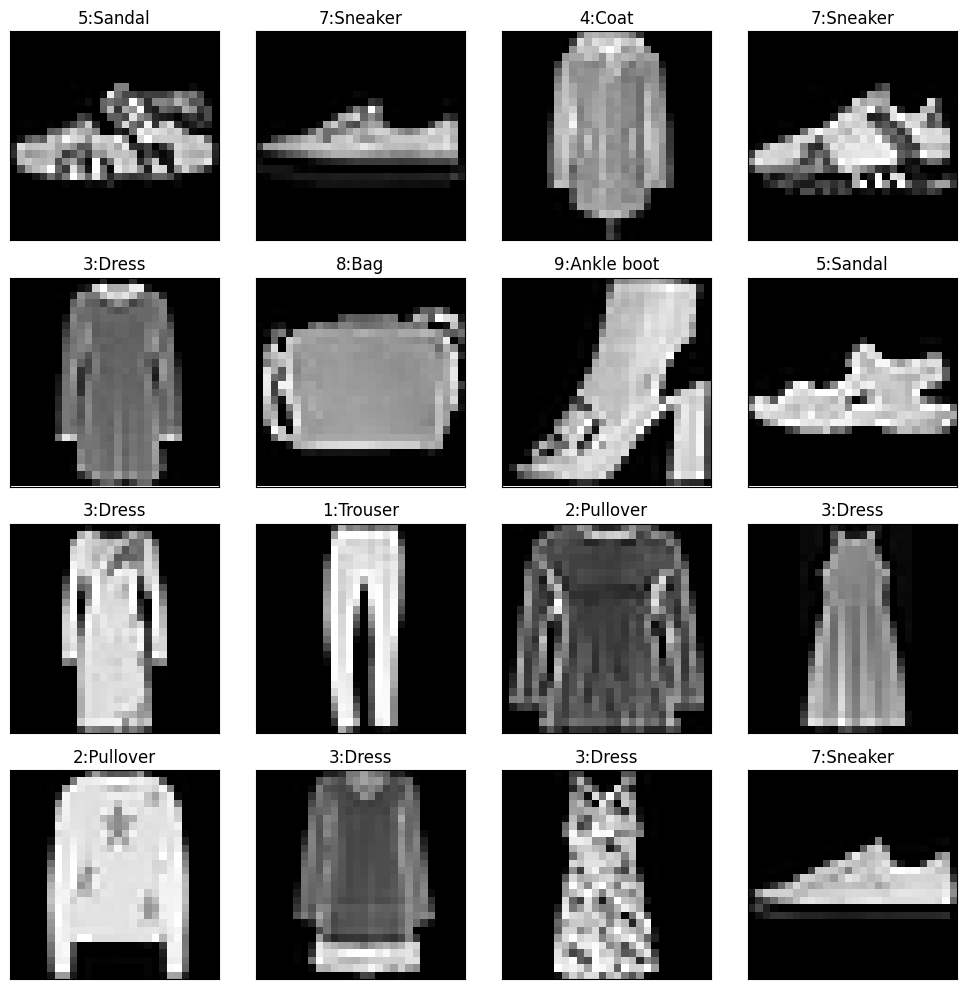

In [8]:
def visualize_images(trainloader, num_images=20):
    fig = plt.figure(figsize=(10, 10))

    # Iterate over the first batch
    images, labels = next(iter(trainloader)) # note: getting the first batch of data.

    #To calculate the number of rows and columns for subplots
    num_rows = 4
    num_cols = int(np.ceil(num_images / num_rows))

    for idx in range(min(num_images, len(images))):
      image, label = images[idx], labels[idx]

      ax = fig.add_subplot(num_rows, num_cols, idx+1, xticks=[], yticks=[])
      ax.imshow(np.squeeze(image), cmap="gray")
      ax.set_title(f"{label.item()}:{class_mapping[label.item()]}")

    fig.tight_layout()
    plt.show()

visualize_images(train_loader, num_images=16)

## 3. Model Architecture

### 3.1 Deep Neural Network Architecture

The network architecture shown below has multiple layers. An input layer, five hidden layers, and an output layer. There are several things to note about this architecture.

1. **Input Data**: The image input data is pre-processed (flattened) from a 2-Dimensional array `[28x28]` to 1-Dimensional vector of length `[784x1]` where the elements in this input vector are the normalized pixel intensities.
2. **Hidden Layers**: We have five hidden layers that contain some number of neurons (that we need to specify). Each of the neurons in these layers has a non-linear activation function (e.g., **ReLU**, Sigmoid, etc.).
3. **Output Layer**: We now have ten neurons in the output layer to represent the ten different classes (cloth items: 0 to 9), instead of a single neuron as in the regression example.
4. **Dense Layers**: All the layers in the network are fully connected, meaning that each neuron in a given layer is fully connected (or dense) to each of the neurons in the previous layer. The **weights** associated with each layer are represented in bold to indicate that these are matrices that contain each of the weights for all the connections between adjacent layers in the network.
5. **Softmax Function**: The values from each of the neurons in the output layer are pased through a `log_softmax()` function to produce a probability score for each of the ten cloth items in the dataset.

6. **Network Output**: The network output ($y’$), is a vector of length ten, that contains the probabilities of each output neuron. Predicting the class label simply requires passing ($y'$) through the `argmax` function to determine the index of the predicted label.
6. **Loss Function**: The loss function used is **Negative Log Likelihood Loss**. It is computed from the ground truth labels ($y$) and the output log probabilities of the network ($y'$). Note that $y$ and $y'$ are both matrices whose shape is `(Bacth Size, Num Classes)`.

Although the diagram looks quite a bit different from the single-layer perceptron in the linear regression example, it is fundamentally very similar in terms of the processing that takes place during training and prediction. We still compute a loss based on the predicted output of the network and the ground truth label of the inputs. Backpropagation is used to compute the gradient of the loss with respect to the weights in the network. An Adam optimizer is used to update the weights in the neural network.

<img src='https://www.dropbox.com/scl/fi/56ks2wo5pem1m58djqsi8/MLP-with-Fashion-MNIST-Pipeline.png?rlkey=b7is8m2cz222fa6x88px2ll79&st=qvlv5i5f&dl=1' align='center' width='1000'>

note: loss function calcuates how much we are doing wrong.
Then based on that, we update the weights that were chosen randomly at the beginning.



## 4. Multi Layer Perceptron Model Implementation.

The following defines an MLP (Multi-Layer Perceptron) model for classifying images into `10` classes using PyTorch `nn` Module. The model consists of five fully connected layers with `ReLU` activations, batch normalization, and dropout for regularization. The input layer processes `28x28` images (flattened to `784` features), and the output layer uses a log-softmax activation function to produce probabilities for the `10` classes.

Here we use log-softmax at the output layers, as Negative Log Likelihood Loss expects the model's outputs in terms of log probabilities. Dropout is used to prevent overfitting by randomly setting some of the activations to zero during training, and this is compensated by a scale factor to maintain the overall sum of activations.

In [9]:
class MLP(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.fc0 = nn.Linear(784, 512) # linear combination based on weights.
        self.bn0 = nn.BatchNorm1d(512) # note: stabalizes the training process. | there are many ways to do that.

        self.fc1 = nn.Linear(512, 256)
        self.bn1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)

        # 3rd layer. Hiddle layer: 128 -> 64 neurons
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)

        # output layer: 64 -> num_classes neurons.
        self.fc4 = nn.Linear(64,num_classes)

        self.dropout = nn.Dropout(p=0.3) # note: dropout layer to reduce overfitting (p=0.3 means 30% dropout.). | dropout is one of the techniques to conquer overfitting.  | avoid memorizing the pattern instead of learning it.

    def forward(self, x):
        #Flatten the input tensor
        x = x.view(x.shape[0], -1) #(B,784)  --> 28x28 = 784

        # First fully connected layer with ReLU, batch norm, and dropout
        x = F.relu(self.bn0(self.fc0(x))) # Either 0 or spiky!
        x = self.dropout(x)

        x = F.relu(self.bn1(self.fc1(x))) # note: no dropout for second layer, why?! It's a design decision. It's not necessary for each layer have a dropout. | we mostly rely on architectures that other researchers found and work on the fine tuning them.
                                          # note: we can easily add more layers and change the architecture to get a better output.

        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        # Output layer with softmax activation
        x = F.relu(self.bn3(self.fc3(x)))
        x = F.log_softmax(self.fc4(x), dim = 1)

        return x

# Instantiate the model.
mlp_model = MLP(num_classes = 10)

Let's look at the parameters and the output shape after each layers.

In [10]:
#A dummy input size of (B,C,H,W) = (1,1,28,28) is passed.
print(summary(mlp_model, input_size = (1,1,28,28), row_settings = ["var_names"]))
# Display the model summary.

Layer (type (var_name))                  Output Shape              Param #
MLP (MLP)                                [1, 10]                   --
├─Linear (fc0)                           [1, 512]                  401,920
├─BatchNorm1d (bn0)                      [1, 512]                  1,024
├─Dropout (dropout)                      [1, 512]                  --
├─Linear (fc1)                           [1, 256]                  131,328
├─BatchNorm1d (bn1)                      [1, 256]                  512
├─Linear (fc2)                           [1, 128]                  32,896
├─BatchNorm1d (bn2)                      [1, 128]                  256
├─Dropout (dropout)                      [1, 128]                  --
├─Linear (fc3)                           [1, 64]                   8,256
├─BatchNorm1d (bn3)                      [1, 64]                   128
├─Linear (fc4)                           [1, 10]                   650
Total params: 576,970
Trainable params: 576,970
Non-trainable

- note: in Output Shape, when we have [1, 512] means we have 512 neurons.
- Each neuron is connected to other neurons, that's why we have such a big number e.g. 576,970

#### **4.1. Training Configuration**

In [11]:
# Define the loss function
criterion = F.nll_loss #Negative Log Likelihood Loss
#  define the optimizer
optimizer = optim.Adam(mlp_model.parameters(), lr = 1e-2) #0.01
#  number of epochs for training. nr. of times we train over all the dataset. | 40 is based on the previous experiments based on the papers, etc.
num_epochs = 40 # note: the model will train for 40 complete passes over the dataset.
#  selecting the device for computation
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

#### **4.2. Model Training**

For training the model, input images, and the labels has to be on the same device, either on `cuda` or `cpu`.

In [12]:
def train(model, trainloader, criterion, optimizer,DEVICE):
    # model
    # data loader
    # function for optimizer.

    model.train() # set the model in training mode.
    model.to(DEVICE)
    running_loss = 0
    correct_predictions = 0
    total_samples = 0

    for images, labels in trainloader:
        images,labels = images.to(DEVICE),labels.to(DEVICE)
        optimizer.zero_grad() # reset tgradients to prevent accumilation from previous batches.
        outputs = model(images)
        loss = criterion(outputs, labels) # compute the loss between predictions and ground truth labels.
        loss.backward() # backpropagation: compute gradients.
        optimizer.step() # update model wights using optimizer.

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, dim=1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    avg_loss = running_loss / len(trainloader)
    accuracy = 100 * correct_predictions / total_samples
    return avg_loss, accuracy

In [13]:
def validation(model, val_loader, criterion,DEVICE):
    model.eval()
    model.to(DEVICE)

    # initialize variables to track loss and accuracy:
    running_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images,labels = images.to(DEVICE),labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1) #(B, class_id)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    avg_loss = running_loss / len(val_loader)
    accuracy = 100 * correct_predictions / total_samples
    return avg_loss, accuracy

note: training loss is usually lower than validation loss.

We will train for **40 epochs** and plot the training accuracy and loss.

In [14]:
def main(model, trainloader, val_loader, epochs=5, DEVICE = "cuda"):

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        train_loss, train_accuracy = train(model, trainloader, criterion, optimizer, DEVICE)
        val_loss, val_accuracy = validation(model, val_loader, criterion, DEVICE)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1:0>2}/{epochs} - Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}% - Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

    # Plotting loss and accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
    plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs + 1), train_accuracies, label='Train Accuracy')
    plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

With an learning rate of 0.01 our MLP Model achieved a highest val accuracy of **90.39%**.

Epoch 01/40 - Train Loss: 0.5596, Train Accuracy: 80.08% - Val Loss: 0.4326, Val Accuracy: 84.14%
Epoch 02/40 - Train Loss: 0.4392, Train Accuracy: 84.28% - Val Loss: 0.3807, Val Accuracy: 85.77%
Epoch 03/40 - Train Loss: 0.3969, Train Accuracy: 85.93% - Val Loss: 0.3801, Val Accuracy: 85.68%
Epoch 04/40 - Train Loss: 0.3739, Train Accuracy: 86.39% - Val Loss: 0.3630, Val Accuracy: 86.48%
Epoch 05/40 - Train Loss: 0.3558, Train Accuracy: 87.13% - Val Loss: 0.3467, Val Accuracy: 87.49%
Epoch 06/40 - Train Loss: 0.3410, Train Accuracy: 87.59% - Val Loss: 0.3391, Val Accuracy: 87.68%
Epoch 07/40 - Train Loss: 0.3268, Train Accuracy: 88.15% - Val Loss: 0.3248, Val Accuracy: 88.27%
Epoch 08/40 - Train Loss: 0.3161, Train Accuracy: 88.47% - Val Loss: 0.3187, Val Accuracy: 88.54%
Epoch 09/40 - Train Loss: 0.3054, Train Accuracy: 88.92% - Val Loss: 0.3104, Val Accuracy: 88.46%
Epoch 10/40 - Train Loss: 0.2958, Train Accuracy: 89.20% - Val Loss: 0.3208, Val Accuracy: 88.43%
Epoch 11/40 - Train 

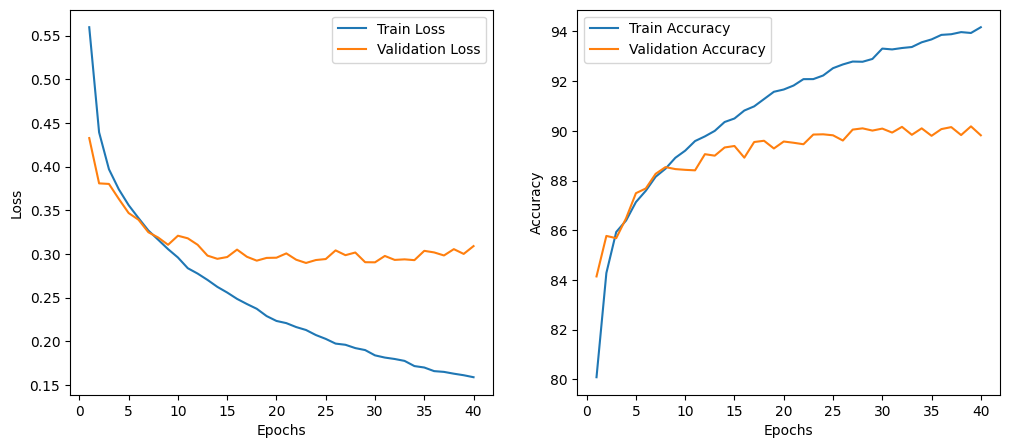

In [15]:
main(mlp_model, train_loader, val_loader, epochs = num_epochs, DEVICE = DEVICE)

## OUTPUT:
Epoch 01/40 - Train Loss: 0.5596, Train Accuracy: 80.08% - Val Loss: 0.4326, Val Accuracy: 84.14%
Epoch 02/40 - Train Loss: 0.4392, Train Accuracy: 84.28% - Val Loss: 0.3807, Val Accuracy: 85.77%
Epoch 03/40 - Train Loss: 0.3969, Train Accuracy: 85.93% - Val Loss: 0.3801, Val Accuracy: 85.68%
Epoch 04/40 - Train Loss: 0.3739, Train Accuracy: 86.39% - Val Loss: 0.3630, Val Accuracy: 86.48%
Epoch 05/40 - Train Loss: 0.3558, Train Accuracy: 87.13% - Val Loss: 0.3467, Val Accuracy: 87.49%
Epoch 06/40 - Train Loss: 0.3410, Train Accuracy: 87.59% - Val Loss: 0.3391, Val Accuracy: 87.68%
Epoch 07/40 - Train Loss: 0.3268, Train Accuracy: 88.15% - Val Loss: 0.3248, Val Accuracy: 88.27%
Epoch 08/40 - Train Loss: 0.3161, Train Accuracy: 88.47% - Val Loss: 0.3187, Val Accuracy: 88.54%
Epoch 09/40 - Train Loss: 0.3054, Train Accuracy: 88.92% - Val Loss: 0.3104, Val Accuracy: 88.46%
Epoch 10/40 - Train Loss: 0.2958, Train Accuracy: 89.20% - Val Loss: 0.3208, Val Accuracy: 88.43%
Epoch 11/40 - Train Loss: 0.2836, Train Accuracy: 89.59% - Val Loss: 0.3178, Val Accuracy: 88.41%
Epoch 12/40 - Train Loss: 0.2774, Train Accuracy: 89.78% - Val Loss: 0.3104, Val Accuracy: 89.06%
Epoch 13/40 - Train Loss: 0.2702, Train Accuracy: 90.00% - Val Loss: 0.2980, Val Accuracy: 89.00%
Epoch 14/40 - Train Loss: 0.2622, Train Accuracy: 90.36% - Val Loss: 0.2943, Val Accuracy: 89.33%
Epoch 15/40 - Train Loss: 0.2557, Train Accuracy: 90.50% - Val Loss: 0.2964, Val Accuracy: 89.39%
Epoch 16/40 - Train Loss: 0.2485, Train Accuracy: 90.82% - Val Loss: 0.3049, Val Accuracy: 88.92%
Epoch 17/40 - Train Loss: 0.2426, Train Accuracy: 90.98% - Val Loss: 0.2967, Val Accuracy: 89.55%
Epoch 18/40 - Train Loss: 0.2371, Train Accuracy: 91.28% - Val Loss: 0.2922, Val Accuracy: 89.60%
Epoch 19/40 - Train Loss: 0.2288, Train Accuracy: 91.57% - Val Loss: 0.2954, Val Accuracy: 89.29%
Epoch 20/40 - Train Loss: 0.2232, Train Accuracy: 91.66% - Val Loss: 0.2956, Val Accuracy: 89.57%
Epoch 21/40 - Train Loss: 0.2207, Train Accuracy: 91.82% - Val Loss: 0.3005, Val Accuracy: 89.52%
Epoch 22/40 - Train Loss: 0.2162, Train Accuracy: 92.08% - Val Loss: 0.2933, Val Accuracy: 89.46%
Epoch 23/40 - Train Loss: 0.2128, Train Accuracy: 92.08% - Val Loss: 0.2896, Val Accuracy: 89.85%
Epoch 24/40 - Train Loss: 0.2070, Train Accuracy: 92.23% - Val Loss: 0.2929, Val Accuracy: 89.86%
Epoch 25/40 - Train Loss: 0.2026, Train Accuracy: 92.52% - Val Loss: 0.2941, Val Accuracy: 89.82%
Epoch 26/40 - Train Loss: 0.1972, Train Accuracy: 92.67% - Val Loss: 0.3040, Val Accuracy: 89.61%
Epoch 27/40 - Train Loss: 0.1959, Train Accuracy: 92.79% - Val Loss: 0.2985, Val Accuracy: 90.05%
Epoch 28/40 - Train Loss: 0.1921, Train Accuracy: 92.78% - Val Loss: 0.3016, Val Accuracy: 90.10%
Epoch 29/40 - Train Loss: 0.1898, Train Accuracy: 92.89% - Val Loss: 0.2905, Val Accuracy: 90.01%
Epoch 30/40 - Train Loss: 0.1838, Train Accuracy: 93.31% - Val Loss: 0.2903, Val Accuracy: 90.09%
Epoch 31/40 - Train Loss: 0.1812, Train Accuracy: 93.28% - Val Loss: 0.2976, Val Accuracy: 89.93%
Epoch 32/40 - Train Loss: 0.1796, Train Accuracy: 93.33% - Val Loss: 0.2931, Val Accuracy: 90.16%
Epoch 33/40 - Train Loss: 0.1774, Train Accuracy: 93.37% - Val Loss: 0.2937, Val Accuracy: 89.84%
Epoch 34/40 - Train Loss: 0.1715, Train Accuracy: 93.56% - Val Loss: 0.2928, Val Accuracy: 90.10%
Epoch 35/40 - Train Loss: 0.1699, Train Accuracy: 93.68% - Val Loss: 0.3035, Val Accuracy: 89.80%
Epoch 36/40 - Train Loss: 0.1657, Train Accuracy: 93.86% - Val Loss: 0.3017, Val Accuracy: 90.07%
Epoch 37/40 - Train Loss: 0.1648, Train Accuracy: 93.89% - Val Loss: 0.2982, Val Accuracy: 90.15%
Epoch 38/40 - Train Loss: 0.1628, Train Accuracy: 93.97% - Val Loss: 0.3054, Val Accuracy: 89.83%
Epoch 39/40 - Train Loss: 0.1610, Train Accuracy: 93.94% - Val Loss: 0.3000, Val Accuracy: 90.18%
Epoch 40/40 - Train Loss: 0.1587, Train Accuracy: 94.17% - Val Loss: 0.3089, Val Accuracy: 89.82%



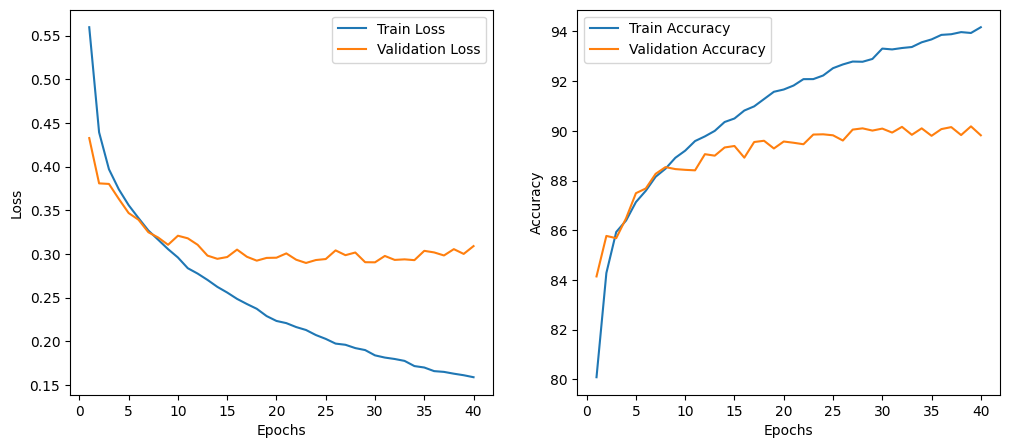

note: the real accuracy is in the last epochs.
note: the best model is the one with highest accuracy which is not the last one in this case.

## 5. Inference Results

We can now predict the results for all the test images, as shown in the code below. Here, we call the `next(iter(val_loader))` to retrieve all the predictions of the first batch, and then we select a specific index from the batch outputs and print out the predicted scores for each class. You can experiment with the code below by setting the test index to various values and see how the highest score is usually associated with the correct value indicated by the ground truth.

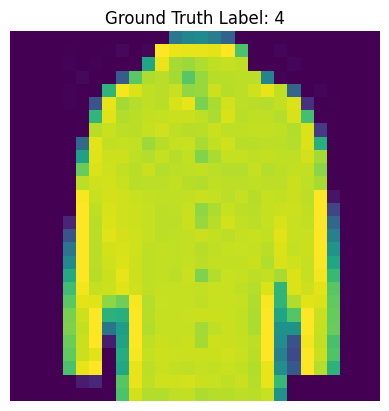

In [16]:
images, gt_labels = next(iter(val_loader)) # select the random image

rand_idx = random.choice(range(len(images)))

plt.imshow(images[rand_idx].squeeze())
plt.title("Ground Truth Label: " + str(int(gt_labels[rand_idx])), fontsize = 12)
plt.axis("off")
plt.show()

In [17]:
# Formatting
bold = f"\033[1m"
reset = f"\033[0m"

In [18]:
mlp_model.eval()

with torch.no_grad(): # disabling gradient computation for efficientcy during inference.
     batch_outputs = mlp_model(images.to(DEVICE)) # note: perfor a forward pas with the selected batch of images on the specific device (GPU/CPU).

# computing softmax probabilities for each class in the batch.
prob_score_batch = batch_outputs.softmax(dim=1).cpu() # move to cpu for easier processing.

prob_score_test_image = prob_score_batch[rand_idx] # probabilities for each class in the batch.
pred_cls_id = prob_score_test_image.argmax() # get the predicted class ID (image of the highest probability).

print("Predictions for each class on the test image:\n")

for idx, cls_prob in enumerate(prob_score_test_image):
    if idx == pred_cls_id:
       print(f"{bold}Class: {idx} - {class_mapping[idx]}, Probability: {cls_prob:.3f}{reset}")
    else:
       print(f"Class: {idx} - {class_mapping[idx]}, Probability: {cls_prob:.3f}")

Predictions for each class on the test image:

Class: 0 - T-shirt/top, Probability: 0.000
Class: 1 - Trouser, Probability: 0.000
Class: 2 - Pullover, Probability: 0.157
Class: 3 - Dress, Probability: 0.000
Class: 4 - Coat, Probability: 0.833
Class: 5 - Sandal, Probability: 0.000
Class: 6 - Shirt, Probability: 0.010
Class: 7 - Sneaker, Probability: 0.000
Class: 8 - Bag, Probability: 0.000
Class: 9 - Ankle boot, Probability: 0.000


#### **5.1. Confusion  matrix**

A confusion matrix is a very common metric that is used to summarize the results of a classification problem. The information is presented in the form of a table or matrix where one axis represents the ground truth labels for each class, and the other axis represents the predicted lables from the network. The entries in the table represent the number of instances from an experiment (which are sometimes represented as percentages rather than counts). Generating a confusion matrix is accomplished by calling the `confusion_matrix` from `sklearn.metrics`, which takes two required arguments which are the list of ground truth labels and the associated predicted lables.

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sn

In [20]:
def prediction_batch(model, batch_inputs):
    model.eval()

    batch_outputs = model(batch_inputs)

    with torch.no_grad():
        batch_probs = batch_outputs.softmax(dim=1) #along num of classes dimension

    batch_cls_ids = batch_probs.argmax(dim=1) # to have the class IDs.

    return batch_cls_ids.cpu()

In [21]:
val_target_labels = []
val_predicted_labels = []

for image_batch, target_batch in val_loader:
    image_batch = image_batch.to(DEVICE)

    batch_pred_cls_id = prediction_batch(mlp_model, image_batch)

    val_predicted_labels.append(batch_pred_cls_id)
    val_target_labels.append(target_batch)

val_target_labels = torch.cat(val_target_labels).numpy()
val_predicted_labels = torch.cat(val_predicted_labels).numpy()

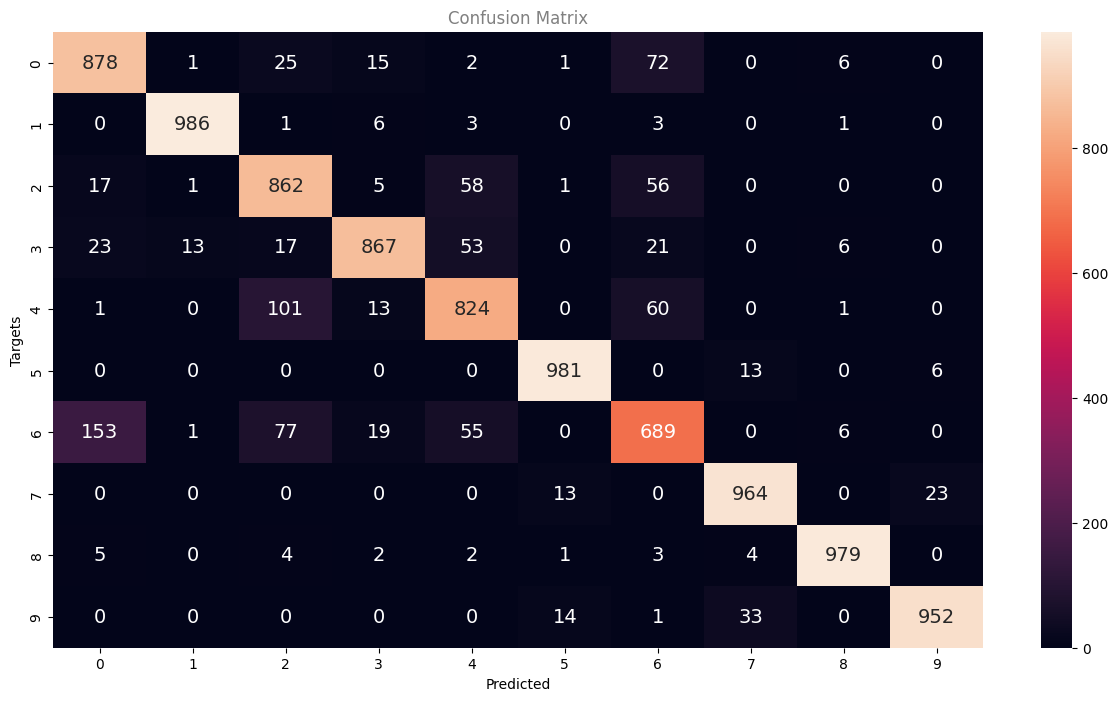

In [22]:
cm = confusion_matrix(y_true=val_target_labels, y_pred = val_predicted_labels)

plt.figure(figsize= [15,8])

# Plot the confusion matrix as a heatmap.
sn.heatmap(cm, annot=True, fmt='d', annot_kws={"size":14})
plt.xlabel("Predicted")
plt.ylabel("Targets")
plt.title(f"Confusion Matrix", color="gray")
plt.show()

0 (T-shirt) -> 6 (Shirt) => 153 => which makes sense.

## 6. Conclusion

In this notebook, we introduced a simple approach for how to model image data for use in a densely connected network to perform multinomial classification. In the next notebook, we will learn about Convolutional Neural Networks (CNNs) that are specifically designed to process image data. The following link contains a really nice interactive web-based animation of several well-known CNN architectures, which is a great place to start getting familiar with them.

* 6.1. https://tensorspace.org/html/playground/lenet.html
* 6.2. https://poloclub.github.io/cnn-explainer/